In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from matplotlib import pyplot as plt

data_path = "../../00_data/01_interim/selected_data_2023.csv"
df = pd.read_csv(data_path, low_memory=False)

df.head()

,YEAR,OPID,pid,hid,housenum,p__wt,p__wt2,p__wt_org,p__wt_org2,KMPS10,...,p__i02008,p__i02012,p__i02013,p__i02014,p__i02015,p__i02016,p__l01038,p__l01042,netflix_next,is_churned
0,2023,10002,10002,100,2,0.077611,0.119846,0.225981,1.416785,NaN,...,1.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0
1,2023,40002,40002,400,2,1.249054,NaN,0.080760,NaN,NaN,...,8.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0
2,2023,40004,40004,400,4,1.421301,NaN,0.086053,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,3.0,NaN,1.0,0
3,2023,100001,100001,1000,1,2.413607,2.733948,4.353450,10.114858,NaN,...,4.0,3.0,NaN,NaN,NaN,NaN,6.0,NaN,1.0,0
4,2023,100002,100002,1000,2,2.331754,2.642048,3.646194,5.876653,NaN,...,8.0,8.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0


### 1. 데이터 기본 정보 확인

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2280 entries, 0 to 2279
Columns: 1522 entries, YEAR to is_churned
dtypes: float64(1431), int64(76), str(15)
memory usage: 26.5 MB


### 2. 타겟 변수 확인

In [5]:
df["is_churned"].value_counts()

is_churned
0    1455
1     825
Name: count, dtype: int64

### 3. 분석에 사용할 컬럼 선택

In [6]:
cols = ['p__d01001','p__d26080','p__d26007','p__d26039','p__d26043','p__d11001','p__d11002','p__d11010','p__d11014','p__d27001','p__d27003','p__d28001','p__d08001','p__d22001','p__d10001','p__d12001','p__a03032','p__d02001','p__d05001','p__d29001','p__d29002','p__d29003','p__d29004','p__d29005','p__d29006','p__d29009']

df_cols = df[cols]
print(df_cols.shape)
df_cols.head()

(2280, 26)


,p__d01001,p__d26080,p__d26007,p__d26039,p__d26043,p__d11001,p__d11002,p__d11010,p__d11014,p__d27001,...,p__a03032,p__d02001,p__d05001,p__d29001,p__d29002,p__d29003,p__d29004,p__d29005,p__d29006,p__d29009
0,5.0,1.0,1.0,190.0,190.0,1,2.0,10.0,10.0,6.0,...,2.0,6,1,2.0,NaN,NaN,NaN,NaN,NaN,NaN
1,11.0,1.0,6.0,120.0,120.0,1,12.0,15.0,10.0,6.0,...,1.0,3,2,2.0,NaN,NaN,NaN,NaN,NaN,NaN
2,10.0,1.0,1.0,180.0,300.0,1,2.0,150.0,270.0,9.0,...,2.0,13,2,2.0,NaN,NaN,NaN,NaN,NaN,NaN
3,10.0,1.0,1.0,120.0,60.0,1,15.0,180.0,180.0,11.0,...,1.0,1,1,1.0,2.0,2.0,1.0,1.0,2.0,2.0
4,11.0,1.0,2.0,60.0,30.0,1,16.0,20.0,20.0,11.0,...,1.0,1,1,2.0,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df_cols = df[cols]

### 4. 결측치 개수 확인

In [8]:

df_cols.isna().sum()

p__d01001       2
p__d26080       0
p__d26007       0
p__d26039       0
p__d26043       0
p__d11001       0
p__d11002     485
p__d11010     485
p__d11014     485
p__d27001     485
p__d27003     485
p__d28001       0
p__d08001       0
p__d22001       0
p__d10001       0
p__d12001       0
p__a03032       6
p__d02001       0
p__d05001       0
p__d29001       0
p__d29002    1785
p__d29003    1785
p__d29004    1785
p__d29005    1785
p__d29006    1785
p__d29009    1785
dtype: int64

In [9]:
# 8. 결측치가 있는 컬럼만 확인
# =========================================
df_cols.isnull().sum()[df_cols.isnull().sum() > 0]

p__d01001       2
p__d11002     485
p__d11010     485
p__d11014     485
p__d27001     485
p__d27003     485
p__a03032       6
p__d29002    1785
p__d29003    1785
p__d29004    1785
p__d29005    1785
p__d29006    1785
p__d29009    1785
dtype: int64

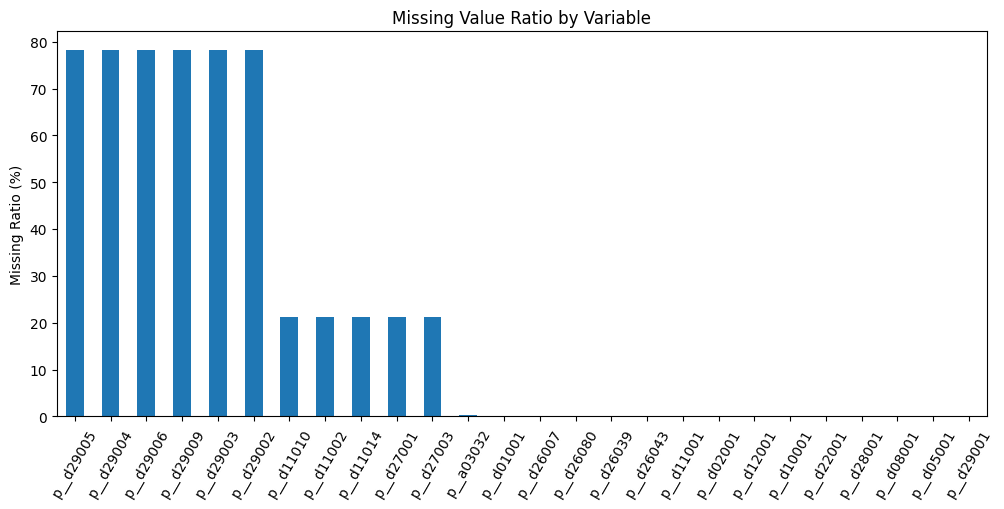

In [11]:
# 11. 결측치 비율 막대그래프
# =========================================
missing_ratio = df_cols.isna().mean() * 100

plt.figure(figsize=(12, 5))
missing_ratio.sort_values(ascending=False).plot(kind='bar')
plt.ylabel("Missing Ratio (%)")
plt.title("Missing Value Ratio by Variable")
plt.xticks(rotation=60)
plt.show()

In [13]:
# 13. 수치형 변수 상관관계 확인
# =========================================
corr = df.select_dtypes(include='number').corr()
corr.head()

,YEAR,OPID,pid,hid,housenum,p__wt,p__wt2,p__wt_org,p__wt_org2,KMPS10,...,p__i02008,p__i02012,p__i02013,p__i02014,p__i02015,p__i02016,p__l01038,p__l01042,netflix_next,is_churned
YEAR,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
OPID,NaN,1.000000,1.000000,1.000000,-0.067571,0.068781,0.048851,-0.019487,-0.298323,NaN,...,0.005174,0.064948,NaN,NaN,NaN,NaN,0.152902,0.084301,-0.024294,-0.021947
pid,NaN,1.000000,1.000000,1.000000,-0.067571,0.068781,0.048851,-0.019487,-0.298323,NaN,...,0.005174,0.064948,NaN,NaN,NaN,NaN,0.152902,0.084301,-0.024294,-0.021947
hid,NaN,1.000000,1.000000,1.000000,-0.067571,0.068781,0.048851,-0.019487,-0.298323,NaN,...,0.005174,0.064948,NaN,NaN,NaN,NaN,0.152902,0.084301,-0.024294,-0.021947
housenum,NaN,-0.067571,-0.067571,-0.067571,1.000000,-0.177520,-0.186128,-0.090818,0.103144,NaN,...,0.022881,0.054246,NaN,NaN,NaN,NaN,-0.088862,-0.036047,-0.043233,-0.037417


In [14]:
# 14. is_churned와의 상관관계 확인
# =========================================
churn_corr = corr['is_churned'].sort_values(ascending=False)
churn_corr

is_churned      1.000000
netflix_next    1.000000
p__a03040       0.598506
p__a03042       0.590273
p__l01018       0.585540
                  ...   
p__d24102            NaN
p__i02013            NaN
p__i02014            NaN
p__i02015            NaN
p__i02016            NaN
Name: is_churned, Length: 1507, dtype: float64

In [15]:
# 15. is_churned와의 상관관계 절댓값 기준 정렬
# =========================================
churn_corr_abs = corr['is_churned'].abs().sort_values(ascending=False)
churn_corr_abs

is_churned      1.000000
netflix_next    1.000000
p__l01019       0.642857
p__a03005       0.632456
p__a03040       0.598506
                  ...   
p__d24102            NaN
p__i02013            NaN
p__i02014            NaN
p__i02015            NaN
p__i02016            NaN
Name: is_churned, Length: 1507, dtype: float64

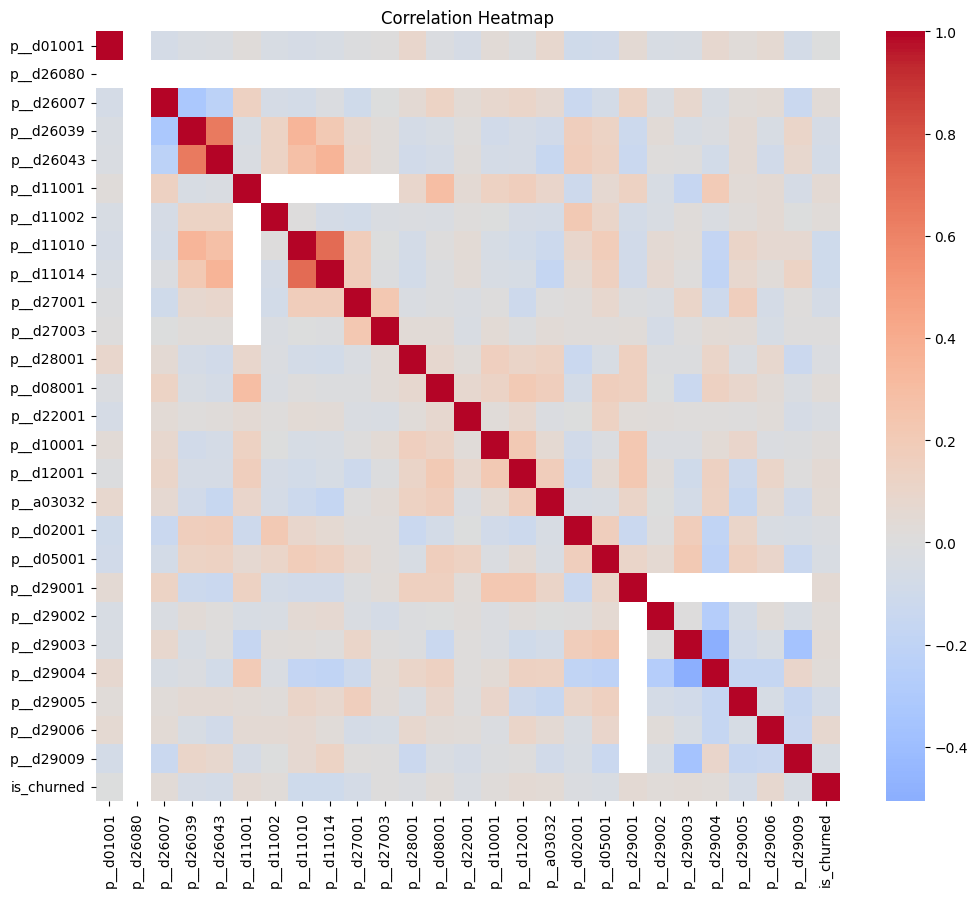

In [17]:
# 16. 선택한 변수(cols) + 타겟 변수 상관관계 히트맵
# =========================================
plt.figure(figsize=(12, 10))
sns.heatmap(df[cols + ['is_churned']].corr(), cmap='coolwarm', center=0)
plt.title("Correlation Heatmap")
plt.show()

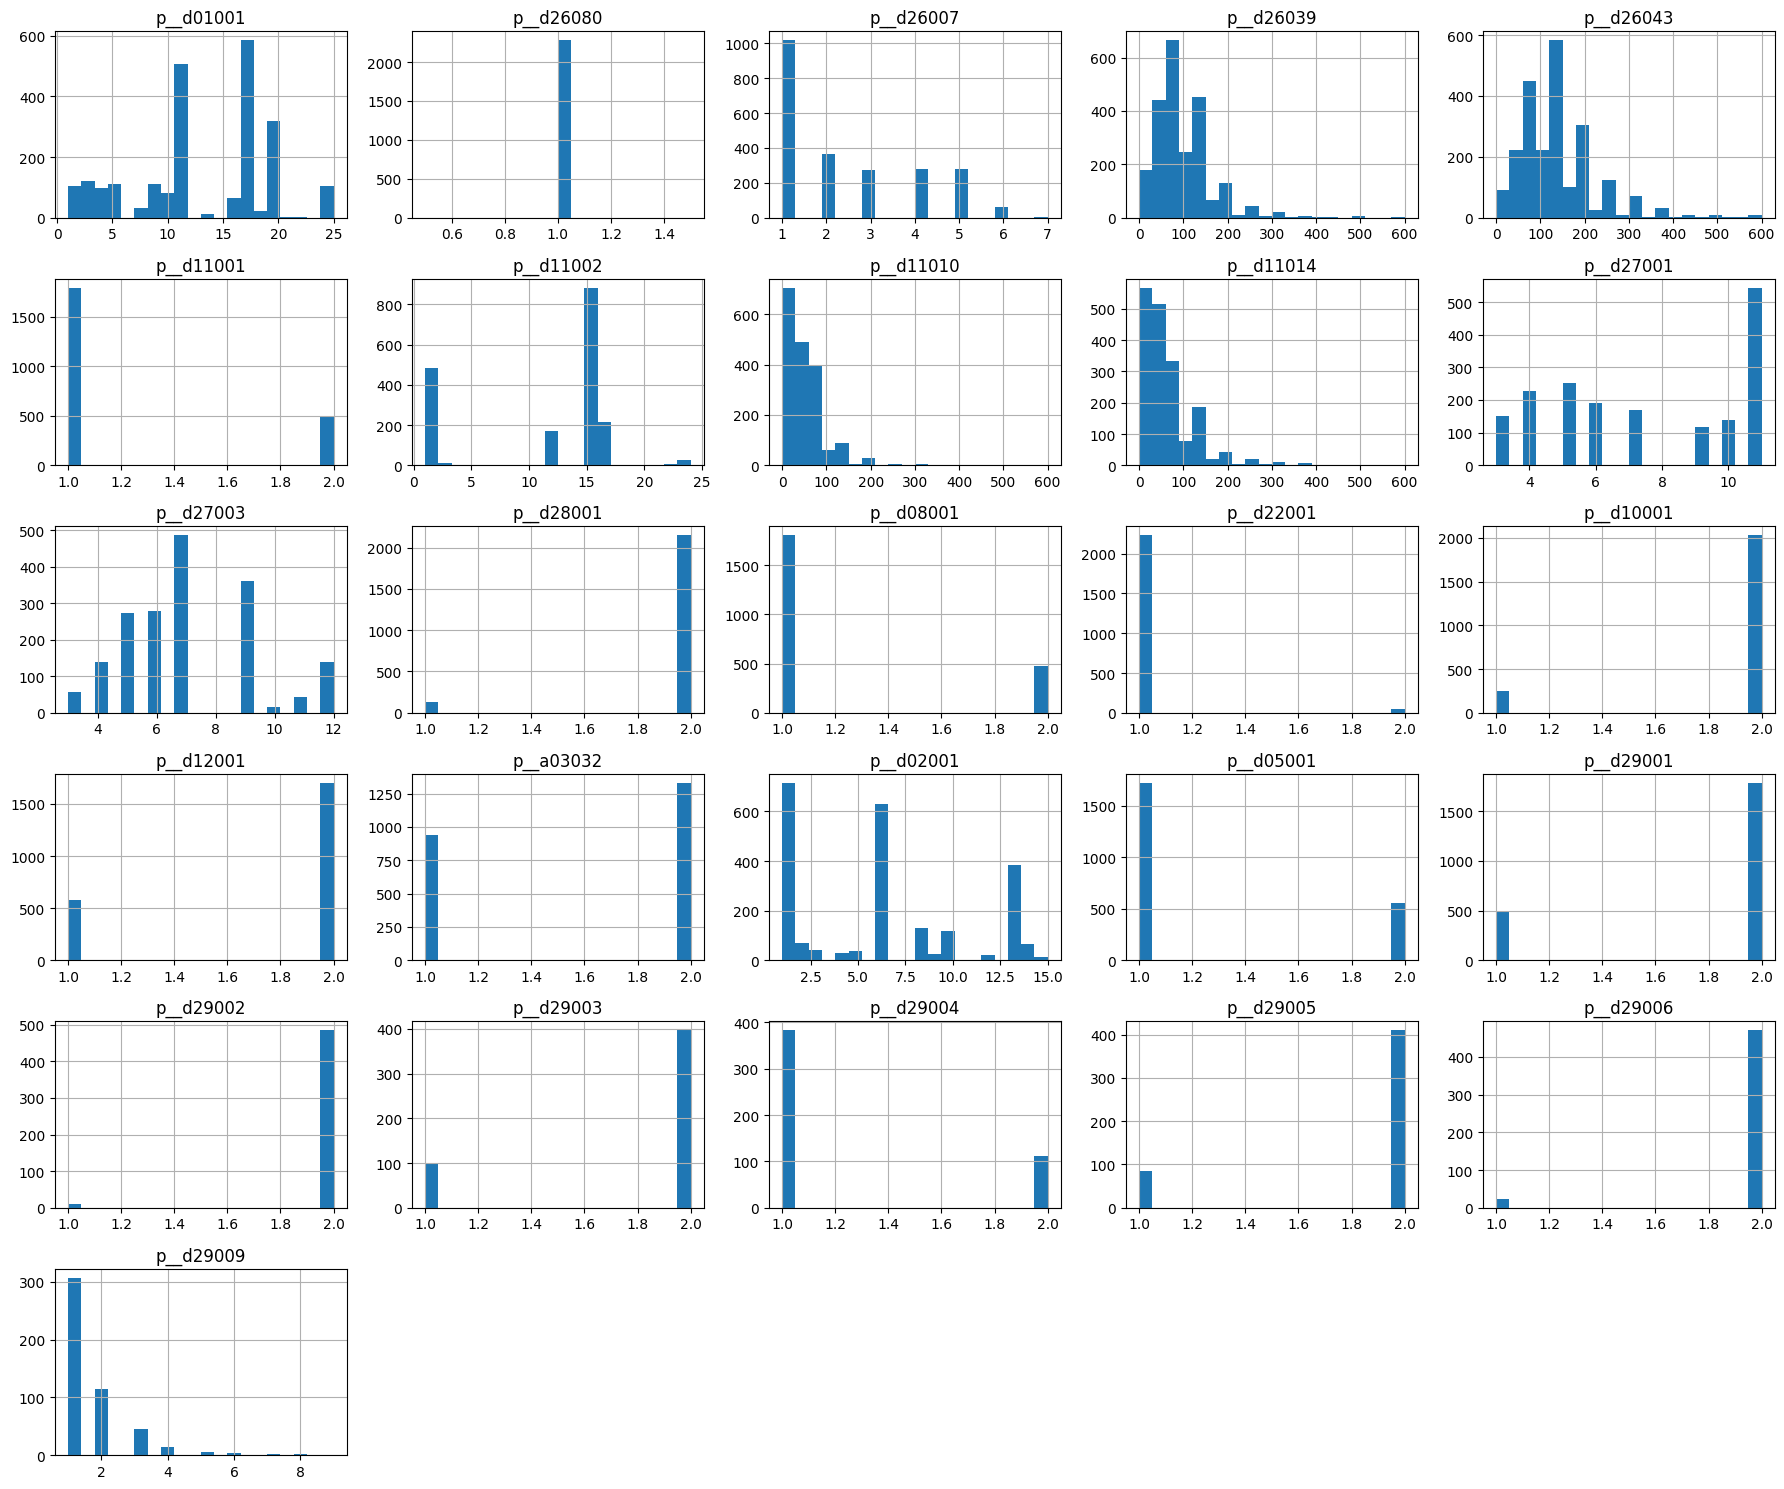

In [18]:
# 17. 변수별 분포 확인
# =========================================
df_cols.hist(figsize=(18, 15), bins=20)
plt.tight_layout()
plt.show()